# 08 - Interpretabilidad mediante SHAP

Este notebook implementa la fase de interpretabilidad del pipeline experimental del TFM **Evaluación del valor incremental de parámetros ECG en riesgo cardiometabólico**.

El objetivo es explicar modelos previamente entrenados, cuantificar la contribución relativa de variables clínicas, variables derivadas mediante NLP y parámetros ECG, y generar evidencia interpretativa para complementar la evaluación incremental realizada en los notebooks anteriores.

Este notebook no entrena nuevos modelos ni modifica datasets previos. Utiliza los artefactos generados por los notebooks 05, 06 y 07.

## 1. Entradas y salidas

### Entradas esperadas

```text
Dataset_E1_Clinico_TFM.xlsx
Dataset_E2_Clinico_NLP_TFM.xlsx
Dataset_E3_Clinico_ECG_TFM.xlsx
Dataset_E4_Clinico_NLP_ECG_TFM.xlsx
Metricas_Modelado_TFM.xlsx
Ranking_Modelos_Escenarios_TFM.xlsx
modelos_entrenados/
```

### Salidas generadas

```text
Resultados_SHAP_TFM.xlsx
Reporte_Interpretabilidad_SHAP_TFM.txt
Graficos_SHAP/shap_summary_beeswarm.png
Graficos_SHAP/shap_summary_bar.png
Graficos_SHAP/shap_importancia_modalidad.png
Graficos_SHAP/shap_top_variables.png
Graficos_SHAP/shap_ecg_variables.png
Graficos_SHAP/shap_waterfall_caso_alto_riesgo.png
Graficos_SHAP/shap_waterfall_caso_bajo_riesgo.png
Graficos_SHAP/shap_force_plot_sample.html
```

## 2. Instalación de dependencias

Esta celda valida e instala dependencias necesarias para la ejecución local.

In [1]:
import importlib.util
import subprocess
import sys

DEPENDENCIAS = {
    "pandas": "pandas",
    "numpy": "numpy",
    "openpyxl": "openpyxl",
    "xlsxwriter": "XlsxWriter",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "matplotlib": "matplotlib",
    "shap": "shap",
}

for modulo, paquete in DEPENDENCIAS.items():
    if importlib.util.find_spec(modulo) is None:
        print(f"Instalando dependencia faltante: {paquete}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", paquete])
        except Exception as exc:
            print(f"No fue posible instalar {paquete}: {exc}")
    else:
        print(f"Dependencia disponible: {modulo}")

Dependencia disponible: pandas
Dependencia disponible: numpy
Dependencia disponible: openpyxl
Dependencia disponible: xlsxwriter
Dependencia disponible: sklearn
Dependencia disponible: joblib
Dependencia disponible: matplotlib
Dependencia disponible: shap


## 3. Carga de librerías y configuración general

In [2]:
import os
import re
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    SHAP_AVAILABLE = False
    SHAP_IMPORT_ERROR = repr(exc)

RANDOM_STATE = 42
TARGET = "RIESGO_CARDIOMETABOLICO"
MAX_SHAP_SAMPLE = 500
MAX_BACKGROUND_SAMPLE = 200
MAX_SHAP_SAMPLE_FALLBACK = 120
MAX_BACKGROUND_SAMPLE_FALLBACK = 50

BASE_DIR = Path.cwd()
OUT_DIR = BASE_DIR
FIG_DIR = OUT_DIR / "Graficos_SHAP"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = BASE_DIR / "modelos_entrenados"

SCENARIO_FILES = {
    "E1_CLINICO": "Dataset_E1_Clinico_TFM.xlsx",
    "E2_CLINICO_NLP": "Dataset_E2_Clinico_NLP_TFM.xlsx",
    "E3_CLINICO_ECG": "Dataset_E3_Clinico_ECG_TFM.xlsx",
    "E4_CLINICO_NLP_ECG": "Dataset_E4_Clinico_NLP_ECG_TFM.xlsx",
}

SCENARIOS_FOR_SHAP = ["E4_CLINICO_NLP_ECG", "E3_CLINICO_ECG"]

MODEL_NAME_TO_KEY = {
    "Logistic Regression": "LogisticRegression",
    "Random Forest": "RandomForest",
    "XGBoost": "XGBoost",
    "LightGBM": "LightGBM",
    "LogisticRegression": "LogisticRegression",
    "RandomForest": "RandomForest",
}

MODEL_KEY_TO_NAME = {
    "LogisticRegression": "Logistic Regression",
    "RandomForest": "Random Forest",
    "XGBoost": "XGBoost",
    "LightGBM": "LightGBM",
}

TRACE_COLS = [
    "PACIENTE_ID", "REGISTRO_ID", "SUBSET_BATERIA", "SUBSET_EXAMENES", "BATERIA_CLUSTER",
    "BATERIA", "BATERIA_ESTRUCTURAL", "CLUSTER_BATERIA", "clave_matching", "archivo_origen", "ruta_relativa",
    "nombre_paciente", "nombre_paciente_norm", "fecha", "fecha_examen", "fecha_atencion_norm",
    "clave_hash_privada", "clave_hash_ecg", "ECG_ID",
]

ENDPOINT_FACTORS = [
    "FLAG_OBESIDAD_IMC",
    "FLAG_PA_SISTOLICA_ALTA",
    "FLAG_PA_DIASTOLICA_ALTA",
    "FLAG_GLICEMIA_ALTA",
    "FLAG_LDL_ALTO",
    "FLAG_TRIGLICERIDOS_ALTOS",
    "FLAG_HDL_BAJO",
    "Diabetes_bin",
    "ANT_HTA",
    "ANT_DIABETES",
    "ANT_DISLIPIDEMIA",
    "ANT_OBESIDAD",
]

OTHER_EXCLUDED = [
    TARGET,
    "INDICE_RIESGO_CARDIOMETABOLICO",
    "num_factores_endpoint_disponibles",
    "endpoint_valido",
]

ECG_VARIABLES = [
    "ECG_HR", "ECG_PR", "ECG_QRS", "ECG_QTC", "ECG_AXIS",
    "QT", "QRS_AXIS", "RV5", "SV1", "RV1", "SV5",
]

NLP_PREFIX = "ANT_"

PATH_METRICS = BASE_DIR / "Metricas_Modelado_TFM.xlsx"
PATH_RANKING = BASE_DIR / "Ranking_Modelos_Escenarios_TFM.xlsx"
PATH_PREDICTIONS = BASE_DIR / "Predicciones_Modelos_TFM.xlsx"
PATH_FEATURES = BASE_DIR / "Variables_Modelado_TFM.xlsx"

OUT_EXCEL = OUT_DIR / "Resultados_SHAP_TFM.xlsx"
OUT_REPORT = OUT_DIR / "Reporte_Interpretabilidad_SHAP_TFM.txt"

FIG_SUMMARY_BEESWARM = FIG_DIR / "shap_summary_beeswarm.png"
FIG_SUMMARY_BAR = FIG_DIR / "shap_summary_bar.png"
FIG_MODALITY = FIG_DIR / "shap_importancia_modalidad.png"
FIG_TOP_VARIABLES = FIG_DIR / "shap_top_variables.png"
FIG_ECG = FIG_DIR / "shap_ecg_variables.png"
FIG_WATERFALL_HIGH = FIG_DIR / "shap_waterfall_caso_alto_riesgo.png"
FIG_WATERFALL_LOW = FIG_DIR / "shap_waterfall_caso_bajo_riesgo.png"
HTML_FORCE_SAMPLE = FIG_DIR / "shap_force_plot_sample.html"

print("BASE_DIR:", BASE_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("FIG_DIR:", FIG_DIR)
print("SHAP disponible:", SHAP_AVAILABLE)
if not SHAP_AVAILABLE:
    print("Error importando SHAP:", SHAP_IMPORT_ERROR)

BASE_DIR: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks
MODEL_DIR: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\modelos_entrenados
FIG_DIR: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Graficos_SHAP
SHAP disponible: True


## 4. Funciones auxiliares

Las funciones siguientes estandarizan carga de archivos, selección de modelos, preparación de matrices, cálculo SHAP y clasificación de variables por modalidad.

In [3]:
def read_excel_first_sheet(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo requerido: {path}")
    return pd.read_excel(path, sheet_name=0)


def read_excel_sheet_if_exists(path: Path, sheet_name: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    xls = pd.ExcelFile(path)
    if sheet_name not in xls.sheet_names:
        return pd.DataFrame()
    return pd.read_excel(path, sheet_name=sheet_name)


def normalize_model_names(df: pd.DataFrame, col: str = "modelo") -> pd.DataFrame:
    if col in df.columns:
        df[col] = df[col].replace({
            "LogisticRegression": "Logistic Regression",
            "RandomForest": "Random Forest",
        })
    return df


def normalize_metric_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {}
    for col in df.columns:
        clean = str(col).strip()
        if clean.lower() in ["roc_auc", "roc-auc", "roc auc", "auroc"]:
            rename_map[col] = "ROC_AUC"
        elif clean.lower() in ["auprc", "pr_auc", "pr-auc", "pr auc", "average_precision"]:
            rename_map[col] = "AUPRC"
        elif clean.lower() in ["f1-score", "f1_score", "f1 score"]:
            rename_map[col] = "F1"
        elif clean != col:
            rename_map[col] = clean
    df = df.rename(columns=rename_map)
    return normalize_model_names(df)


def get_feature_columns(df: pd.DataFrame) -> list:
    excluded = set(TRACE_COLS + ENDPOINT_FACTORS + OTHER_EXCLUDED)
    excluded_norm = {str(c).strip().lower() for c in excluded}
    features = []
    for col in df.columns:
        col_norm = str(col).strip().lower()
        if str(col).startswith("Unnamed"):
            continue
        if col in excluded or col_norm in excluded_norm:
            continue
        features.append(col)
    if not features:
        raise ValueError("No quedan variables predictoras después de aplicar exclusiones")
    return features


def find_battery_column(df: pd.DataFrame):
    for col in ["SUBSET_BATERIA", "SUBSET_EXAMENES", "BATERIA", "BATERIA_ESTRUCTURAL", "BATERIA_CLUSTER"]:
        if col in df.columns:
            return col
    return None


def model_key_from_name(model_name: str) -> str:
    return MODEL_NAME_TO_KEY.get(model_name, model_name)


def model_path_for(scenario: str, model_name: str) -> Path:
    model_key = model_key_from_name(model_name)
    return MODEL_DIR / scenario / f"{model_key}.joblib"


def load_pipeline(scenario: str, model_name: str):
    path = model_path_for(scenario, model_name)
    if not path.exists():
        raise FileNotFoundError(f"No existe modelo entrenado: {path}")
    return joblib.load(path), path


def select_models_to_explain(metrics: pd.DataFrame, ranking: pd.DataFrame) -> pd.DataFrame:
    # Fuente preferente: ranking generado por notebook 07.
    if not ranking.empty and {"escenario", "modelo"}.issubset(ranking.columns):
        candidate = ranking.copy()
        candidate = normalize_metric_columns(candidate)
        if "rank_escenario" in candidate.columns:
            selected = candidate[candidate["rank_escenario"].eq(1)].copy()
        else:
            selected = (
                candidate.sort_values(["escenario", "AUPRC", "ROC_AUC", "F1"], ascending=[True, False, False, False])
                         .groupby("escenario")
                         .head(1)
                         .copy()
            )
    else:
        candidate = normalize_metric_columns(metrics.copy())
        selected = (
            candidate.sort_values(["escenario", "AUPRC", "ROC_AUC", "F1"], ascending=[True, False, False, False])
                     .groupby("escenario")
                     .head(1)
                     .copy()
        )

    selected = selected[selected["escenario"].isin(SCENARIOS_FOR_SHAP)].copy()

    # Prioridad interpretativa: multimodal completo primero; luego clínico + ECG.
    selected["orden_interpretacion"] = selected["escenario"].map({"E4_CLINICO_NLP_ECG": 1, "E3_CLINICO_ECG": 2}).fillna(99)
    selected = selected.sort_values(["orden_interpretacion", "AUPRC", "ROC_AUC", "F1"], ascending=[True, False, False, False])
    return selected


def clean_transformed_feature_name(name: str, original_features: list) -> str:
    s = str(name)
    s = re.sub(r"^(num|cat|remainder)__", "", s)
    # Para one-hot, recuperar el nombre original mediante prefijo más largo.
    candidates = sorted(original_features, key=len, reverse=True)
    for base in candidates:
        if s == base or s.startswith(base + "_"):
            return base
    return s


def get_transformed_feature_names(preprocessor, original_features: list) -> list:
    try:
        names = list(preprocessor.get_feature_names_out())
    except Exception:
        names = list(original_features)
    return names


def to_dense_array(matrix):
    if hasattr(matrix, "toarray"):
        return matrix.toarray()
    return np.asarray(matrix)


def extract_numeric_scalar(value):
    """Convierte escalares, arrays de un elemento o strings tipo '[1.16440624E-1]' a float."""
    if value is None:
        return np.nan
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(value).ravel()
        if arr.size == 0:
            return np.nan
        # Para expected_value/base_values vectoriales se utiliza la clase positiva si existe.
        selected = arr[1] if arr.size > 1 else arr[0]
        return extract_numeric_scalar(selected)
    if isinstance(value, str):
        s = value.strip()
        if s.startswith("[") and s.endswith("]"):
            s = s[1:-1].strip()
        s = s.replace(",", ".")
        return float(s)
    return float(value)


def to_numeric_1d(values, name: str = "values") -> np.ndarray:
    if isinstance(values, pd.Series):
        raw = values.to_numpy()
    else:
        raw = np.asarray(values)
    if raw.ndim == 2:
        if raw.shape[1] >= 2:
            raw = raw[:, 1]
        elif raw.shape[1] == 1:
            raw = raw[:, 0]
    raw = np.asarray(raw, dtype=object).reshape(-1)
    out = np.array([extract_numeric_scalar(v) for v in raw], dtype=float)
    if np.isnan(out).any():
        raise ValueError(f"{name}: contiene valores no convertibles a float")
    return out


def predict_positive_from_estimator(estimator, data: np.ndarray) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        return to_numeric_1d(estimator.predict_proba(data), name="predict_proba_estimator")
    if hasattr(estimator, "decision_function"):
        score = to_numeric_1d(estimator.decision_function(data), name="decision_function_estimator")
        return (score - score.min()) / (score.max() - score.min() + 1e-12)
    return to_numeric_1d(estimator.predict(data), name="predict_estimator")


def compute_shap_values(estimator, model_key: str, X_trans_dense: np.ndarray, background: np.ndarray, transformed_names: list):
    """Calcula SHAP con fallback para incompatibilidades entre SHAP y XGBoost.

    Algunas combinaciones de versiones de xgboost/shap serializan base_score como string
    con formato '[1.16440624E-1]'. En ese caso TreeExplainer puede fallar al intentar
    convertir dicho valor a float. El fallback usa un explicador agnóstico sobre
    predict_proba de la clase positiva, manteniendo el análisis sin modificar el modelo.
    """
    try:
        if model_key in ["RandomForest", "XGBoost", "LightGBM"]:
            explainer = shap.TreeExplainer(estimator)
            raw_shap = explainer.shap_values(X_trans_dense)
            expected_value = normalize_expected_value(explainer.expected_value)
            return raw_shap, expected_value, "TreeExplainer"
        if model_key == "LogisticRegression":
            explainer = shap.LinearExplainer(estimator, background)
            raw_shap = explainer.shap_values(X_trans_dense)
            expected_value = normalize_expected_value(explainer.expected_value)
            return raw_shap, expected_value, "LinearExplainer"
    except ValueError as exc:
        msg = str(exc)
        if "could not convert string to float" not in msg:
            raise
        print(f"TreeExplainer no compatible para {model_key}: {msg}")
        print("Se utiliza fallback agnóstico SHAP sobre predict_proba de clase positiva.")

    # Fallback controlado para modelos no soportados o incompatibilidad de versión.
    X_eval = X_trans_dense
    bg = background
    masker = shap.maskers.Independent(bg)
    explainer = shap.Explainer(lambda data: predict_positive_from_estimator(estimator, data), masker, feature_names=transformed_names)
    raw_shap = explainer(X_eval)
    expected_value = normalize_expected_value(raw_shap.base_values)
    return raw_shap, expected_value, "GenericExplainer"



def normalize_shap_values(shap_values):
    # SHAP para clasificación binaria puede devolver list[class], Explanation o ndarray.
    if isinstance(shap_values, list):
        if len(shap_values) > 1:
            return np.asarray(shap_values[1])
        return np.asarray(shap_values[0])
    if hasattr(shap_values, "values"):
        vals = shap_values.values
    else:
        vals = shap_values
    vals = np.asarray(vals)
    # Algunas versiones devuelven shape (n, p, classes).
    if vals.ndim == 3:
        vals = vals[:, :, 1] if vals.shape[2] > 1 else vals[:, :, 0]
    return vals


def normalize_expected_value(expected_value):
    # expected_value/base_values puede venir como escalar, vector, ndarray o string serializado.
    if isinstance(expected_value, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(expected_value).ravel()
        if arr.size == 0:
            return 0.0
        if arr.size > 1:
            try:
                return extract_numeric_scalar(arr[1])
            except Exception:
                return float(np.nanmean([extract_numeric_scalar(v) for v in arr]))
        return extract_numeric_scalar(arr[0])
    return extract_numeric_scalar(expected_value)


def infer_modality(variable: str) -> str:
    if variable in ECG_VARIABLES or variable.startswith("ECG_"):
        return "ECG"
    if variable.startswith(NLP_PREFIX):
        return "NLP"
    if variable in TRACE_COLS:
        return "CONTROL"
    return "CLINICA"


def build_shap_importance(shap_matrix: np.ndarray, transformed_names: list, original_features: list) -> pd.DataFrame:
    mean_abs = np.abs(shap_matrix).mean(axis=0)
    rows = []
    for name, val in zip(transformed_names, mean_abs):
        original = clean_transformed_feature_name(name, original_features)
        rows.append({
            "feature_transformada": name,
            "variable_original": original,
            "modalidad": infer_modality(original),
            "shap_abs_mean": float(val),
        })
    df = pd.DataFrame(rows)
    agg = (
        df.groupby(["variable_original", "modalidad"], as_index=False)["shap_abs_mean"]
          .sum()
          .sort_values("shap_abs_mean", ascending=False)
    )
    total = agg["shap_abs_mean"].sum()
    agg["shap_importancia_pct"] = np.where(total > 0, agg["shap_abs_mean"] / total * 100, 0)
    agg["rank_global"] = np.arange(1, len(agg) + 1)
    return agg


def plot_bar_dataframe(df: pd.DataFrame, x_col: str, y_col: str, title: str, output_path: Path, rotation: int = 45):
    plt.figure(figsize=(12, 6))
    plt.bar(df[x_col].astype(str), df[y_col])
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

## 5. Carga de métricas, ranking y datasets

Se cargan las métricas del modelado predictivo y el ranking consolidado generado por la evaluación incremental. Si el ranking no existe, el notebook selecciona modelos directamente desde las métricas globales.

In [4]:
if not SHAP_AVAILABLE:
    raise ImportError("SHAP no está disponible. Revisar instalación antes de continuar.")

metrics = read_excel_first_sheet(PATH_METRICS)
metrics = normalize_metric_columns(metrics)

ranking = read_excel_sheet_if_exists(PATH_RANKING, "RANKING_COMPLETO")
if ranking.empty:
    ranking = read_excel_first_sheet(PATH_RANKING) if PATH_RANKING.exists() else pd.DataFrame()
ranking = normalize_metric_columns(ranking) if not ranking.empty else ranking

features_metadata = read_excel_first_sheet(PATH_FEATURES) if PATH_FEATURES.exists() else pd.DataFrame()

print("Métricas cargadas:", metrics.shape)
print("Ranking cargado:", ranking.shape if not ranking.empty else "NO DISPONIBLE")
print("Metadata de variables:", features_metadata.shape if not features_metadata.empty else "NO DISPONIBLE")

available_scenarios = sorted(metrics["escenario"].dropna().unique()) if "escenario" in metrics.columns else []
available_models = sorted(metrics["modelo"].dropna().unique()) if "modelo" in metrics.columns else []
print("Escenarios disponibles:", available_scenarios)
print("Modelos disponibles:", available_models)

Métricas cargadas: (16, 27)
Ranking cargado: (16, 28)
Metadata de variables: (134, 6)
Escenarios disponibles: ['E1_CLINICO', 'E2_CLINICO_NLP', 'E3_CLINICO_ECG', 'E4_CLINICO_NLP_ECG']
Modelos disponibles: ['LightGBM', 'Logistic Regression', 'Random Forest', 'XGBoost']


## 6. Selección reproducible de modelos para interpretación

El análisis SHAP se aplica sobre el mejor modelo disponible por escenario, priorizando `AUPRC`, luego `ROC_AUC` y finalmente `F1`.

La interpretación principal se centra en `E4_CLINICO_NLP_ECG`, y la interpretación comparativa se aplica sobre `E3_CLINICO_ECG` cuando el modelo entrenado está disponible.

In [5]:
selected_models = select_models_to_explain(metrics, ranking)
if selected_models.empty:
    raise ValueError("No se encontraron modelos seleccionables para SHAP en E4_CLINICO_NLP_ECG o E3_CLINICO_ECG.")

selected_models["modelo_key"] = selected_models["modelo"].map(model_key_from_name)
selected_models["ruta_modelo"] = selected_models.apply(lambda r: str(model_path_for(r["escenario"], r["modelo"])), axis=1)
selected_models["modelo_disponible"] = selected_models["ruta_modelo"].apply(lambda p: Path(p).exists())

display_cols = [c for c in ["escenario", "modelo", "modelo_key", "AUPRC", "ROC_AUC", "F1", "ruta_modelo", "modelo_disponible"] if c in selected_models.columns]
display(selected_models[display_cols])

selected_available = selected_models[selected_models["modelo_disponible"]].copy()
if selected_available.empty:
    raise FileNotFoundError("Los modelos seleccionados no existen en modelos_entrenados/. Ejecutar primero el notebook 06.")

,escenario,modelo,modelo_key,AUPRC,ROC_AUC,F1,ruta_modelo,modelo_disponible
12,E4_CLINICO_NLP_ECG,XGBoost,XGBoost,0.981672,0.996921,0.947368,e:\Capacitacion 2025\Magister en Inteligencia ...,True
8,E3_CLINICO_ECG,XGBoost,XGBoost,0.980673,0.996768,0.947368,e:\Capacitacion 2025\Magister en Inteligencia ...,True


## 7. Validación de datasets y exclusión de leakage

Los factores utilizados para construir el endpoint se excluyen de la matriz predictora. Las columnas de trazabilidad se conservan para auditoría, análisis estructural y selección de casos locales, pero no se usan como predictores.

In [6]:
datasets = {}
for scenario in selected_available["escenario"].unique():
    path = BASE_DIR / SCENARIO_FILES[scenario]
    if not path.exists():
        raise FileNotFoundError(f"No existe dataset para {scenario}: {path}")
    df = read_excel_first_sheet(path)
    if TARGET not in df.columns:
        raise ValueError(f"El dataset {scenario} no contiene {TARGET}.")
    forbidden_present = [c for c in ENDPOINT_FACTORS if c in get_feature_columns(df)]
    if forbidden_present:
        raise ValueError(f"Variables de endpoint presentes como predictoras en {scenario}: {forbidden_present}")
    datasets[scenario] = df
    print(f"{scenario}: {df.shape[0]} registros, {df.shape[1]} columnas, batería={find_battery_column(df)}")

E4_CLINICO_NLP_ECG: 3779 registros, 52 columnas, batería=SUBSET_BATERIA
E3_CLINICO_ECG: 3779 registros, 40 columnas, batería=SUBSET_BATERIA


## 8. Cálculo SHAP

Para cada escenario seleccionado se carga el pipeline entrenado, se transforma la matriz de predictores con el mismo preprocesador usado durante entrenamiento y se calculan valores SHAP sobre una muestra controlada para mantener tiempos de ejecución razonables.

In [7]:
shap_results = []
importance_global_rows = []
importance_modality_rows = []
importance_ecg_rows = []
local_rows = []
shap_context = {}

for _, row in selected_available.iterrows():
    scenario = row["escenario"]
    model_name = row["modelo"]
    model_key = model_key_from_name(model_name)
    print("=" * 80)
    print(f"Calculando SHAP para {scenario} | {model_name}")

    df = datasets[scenario].copy()
    feature_cols = get_feature_columns(df)
    X = df[feature_cols].copy()
    y = df[TARGET].astype(int)

    pipeline, model_path = load_pipeline(scenario, model_name)
    preprocessor = pipeline.named_steps.get("preprocessor")
    estimator = pipeline.named_steps.get("model")
    if preprocessor is None or estimator is None:
        raise ValueError(f"El modelo {model_path} no tiene pasos esperados: preprocessor/model")

    sample_n = min(MAX_SHAP_SAMPLE, len(X))
    sample_df = X.sample(n=sample_n, random_state=RANDOM_STATE)
    sample_index = sample_df.index
    y_sample = y.loc[sample_index]

    X_trans = preprocessor.transform(sample_df)
    X_trans_dense = to_dense_array(X_trans)
    transformed_names = get_transformed_feature_names(preprocessor, feature_cols)

    if len(transformed_names) != X_trans_dense.shape[1]:
        transformed_names = [f"feature_{i}" for i in range(X_trans_dense.shape[1])]

    background_n = min(MAX_BACKGROUND_SAMPLE, X_trans_dense.shape[0])
    background = X_trans_dense[:background_n]

    raw_shap, expected_value, explainer_type = compute_shap_values(
        estimator=estimator,
        model_key=model_key,
        X_trans_dense=X_trans_dense,
        background=background,
        transformed_names=transformed_names,
    )

    shap_matrix = normalize_shap_values(raw_shap)
    if shap_matrix.shape[1] != X_trans_dense.shape[1]:
        raise ValueError(f"Dimensión SHAP incompatible para {scenario} | {model_name}: {shap_matrix.shape} vs {X_trans_dense.shape}")

    importance = build_shap_importance(shap_matrix, transformed_names, feature_cols)
    importance["escenario"] = scenario
    importance["modelo"] = model_name
    importance_global_rows.append(importance)

    modality = (
        importance.groupby("modalidad", as_index=False)["shap_abs_mean"]
        .sum()
        .sort_values("shap_abs_mean", ascending=False)
    )
    total_mod = modality["shap_abs_mean"].sum()
    modality["shap_importancia_pct"] = np.where(total_mod > 0, modality["shap_abs_mean"] / total_mod * 100, 0)
    modality["escenario"] = scenario
    modality["modelo"] = model_name
    importance_modality_rows.append(modality)

    ecg_importance = importance[importance["modalidad"].eq("ECG")].copy()
    ecg_importance["en_top_10"] = ecg_importance["rank_global"].le(10)
    ecg_importance["en_top_20"] = ecg_importance["rank_global"].le(20)
    importance_ecg_rows.append(ecg_importance)

    y_score = to_numeric_1d(
        pipeline.predict_proba(sample_df) if hasattr(pipeline, "predict_proba") else pipeline.decision_function(sample_df),
        name="y_score_local",
    )
    y_pred = (y_score >= 0.5).astype(int)
    local = pd.DataFrame({
        "escenario": scenario,
        "modelo": model_name,
        "index_original": sample_index,
        "y_real": y_sample.values,
        "y_pred": y_pred,
        "y_score": y_score,
    })
    for trace_col in ["PACIENTE_ID", "REGISTRO_ID", "SUBSET_BATERIA", "SUBSET_EXAMENES", "BATERIA_CLUSTER"]:
        if trace_col in df.columns:
            local[trace_col] = df.loc[sample_index, trace_col].values
    local_rows.append(local)

    shap_context[(scenario, model_name)] = {
        "X_sample_original": sample_df,
        "X_trans_dense": X_trans_dense,
        "shap_matrix": shap_matrix,
        "expected_value": expected_value,
        "transformed_names": transformed_names,
        "feature_cols": feature_cols,
        "importance": importance,
        "modality": modality,
        "local": local,
        "model_path": str(model_path),
        "explainer_type": explainer_type,
    }

importance_global = pd.concat(importance_global_rows, ignore_index=True) if importance_global_rows else pd.DataFrame()
importance_modality = pd.concat(importance_modality_rows, ignore_index=True) if importance_modality_rows else pd.DataFrame()
importance_ecg = pd.concat(importance_ecg_rows, ignore_index=True) if importance_ecg_rows else pd.DataFrame()
local_interpretability = pd.concat(local_rows, ignore_index=True) if local_rows else pd.DataFrame()

print("Importancia global:", importance_global.shape)
print("Importancia por modalidad:", importance_modality.shape)
print("Importancia ECG:", importance_ecg.shape)
print("Interpretabilidad local:", local_interpretability.shape)

Calculando SHAP para E4_CLINICO_NLP_ECG | XGBoost
TreeExplainer no compatible para XGBoost: could not convert string to float: '[1.16440624E-1]'
Se utiliza fallback agnóstico SHAP sobre predict_proba de clase positiva.


PermutationExplainer explainer: 501it [00:33, 12.99it/s]                         


Calculando SHAP para E3_CLINICO_ECG | XGBoost
TreeExplainer no compatible para XGBoost: could not convert string to float: '[1.16440624E-1]'
Se utiliza fallback agnóstico SHAP sobre predict_proba de clase positiva.


PermutationExplainer explainer: 501it [00:27, 11.45it/s]                         

Importancia global: (78, 7)
Importancia por modalidad: (5, 5)
Importancia ECG: (22, 9)
Interpretabilidad local: (1000, 11)


## 9. Resultados de importancia global

Se consolida el ranking de variables por importancia SHAP absoluta media.

In [8]:
if importance_global.empty:
    raise ValueError("No se generaron resultados SHAP.")

principal_key = None
for key in shap_context:
    if key[0] == "E4_CLINICO_NLP_ECG":
        principal_key = key
        break
if principal_key is None:
    principal_key = next(iter(shap_context.keys()))

principal_importance = shap_context[principal_key]["importance"].copy()
principal_importance = principal_importance.sort_values("rank_global")

display(principal_importance.head(20))
display(importance_modality.sort_values(["escenario", "shap_abs_mean"], ascending=[True, False]))
display(importance_ecg.sort_values(["escenario", "rank_global"]).head(30))

,variable_original,modalidad,shap_abs_mean,shap_importancia_pct,rank_global,escenario,modelo
26,IMC_num,CLINICA,0.062287,23.029893,1,E4_CLINICO_NLP_ECG,XGBoost
24,HDL_mg_dl,CLINICA,0.047763,17.660054,2,E4_CLINICO_NLP_ECG,XGBoost
27,LDL_mg_dl,CLINICA,0.045855,16.954583,3,E4_CLINICO_NLP_ECG,XGBoost
30,PA_Diastolica_mmHg,CLINICA,0.025988,9.608882,4,E4_CLINICO_NLP_ECG,XGBoost
31,PA_Sistolica_mmHg,CLINICA,0.024404,9.022960,5,E4_CLINICO_NLP_ECG,XGBoost
41,Trigliceridos_mg_dl,CLINICA,0.022164,8.195063,6,E4_CLINICO_NLP_ECG,XGBoost
23,Glicemia_mg_dl,CLINICA,0.017631,6.518894,7,E4_CLINICO_NLP_ECG,XGBoost
12,Altura_m,CLINICA,0.004426,1.636485,8,E4_CLINICO_NLP_ECG,XGBoost
22,Edad,CLINICA,0.004147,1.533321,9,E4_CLINICO_NLP_ECG,XGBoost
32,Peso_kg,CLINICA,0.003687,1.363302,10,E4_CLINICO_NLP_ECG,XGBoost


,modalidad,shap_abs_mean,shap_importancia_pct,escenario,modelo
3,CLINICA,0.270824,100.000000,E3_CLINICO_ECG,XGBoost
4,ECG,0.000000,0.000000,E3_CLINICO_ECG,XGBoost
0,CLINICA,0.269889,99.788591,E4_CLINICO_NLP_ECG,XGBoost
1,NLP,0.000572,0.211409,E4_CLINICO_NLP_ECG,XGBoost
2,ECG,0.000000,0.000000,E4_CLINICO_NLP_ECG,XGBoost


,variable_original,modalidad,shap_abs_mean,shap_importancia_pct,rank_global,escenario,modelo,en_top_10,en_top_20
11,SV5,ECG,0.0,0.0,19,E3_CLINICO_ECG,XGBoost,False,True
12,RV1,ECG,0.0,0.0,20,E3_CLINICO_ECG,XGBoost,False,True
13,SV1,ECG,0.0,0.0,21,E3_CLINICO_ECG,XGBoost,False,False
14,RV5,ECG,0.0,0.0,22,E3_CLINICO_ECG,XGBoost,False,False
15,QT,ECG,0.0,0.0,24,E3_CLINICO_ECG,XGBoost,False,False
16,QRS_AXIS,ECG,0.0,0.0,25,E3_CLINICO_ECG,XGBoost,False,False
17,ECG_QTC,ECG,0.0,0.0,28,E3_CLINICO_ECG,XGBoost,False,False
18,ECG_QRS,ECG,0.0,0.0,29,E3_CLINICO_ECG,XGBoost,False,False
19,ECG_PR,ECG,0.0,0.0,30,E3_CLINICO_ECG,XGBoost,False,False
20,ECG_HR,ECG,0.0,0.0,31,E3_CLINICO_ECG,XGBoost,False,False


## 10. Análisis por subconjunto estructural

Si el dataset del escenario interpretado contiene `SUBSET_BATERIA` o una columna equivalente, se calcula una aproximación de importancia SHAP por subconjunto estructural.

In [9]:
shap_by_battery_rows = []

for (scenario, model_name), ctx in shap_context.items():
    df = datasets[scenario]
    battery_col = find_battery_column(df)
    if battery_col is None:
        continue

    local = ctx["local"].copy()
    if battery_col not in local.columns:
        continue

    shap_matrix = ctx["shap_matrix"]
    transformed_names = ctx["transformed_names"]
    feature_cols = ctx["feature_cols"]

    for battery_value in sorted(local[battery_col].dropna().unique()):
        mask = local[battery_col].eq(battery_value).values
        if mask.sum() < 5:
            continue
        imp = build_shap_importance(shap_matrix[mask], transformed_names, feature_cols)
        imp["escenario"] = scenario
        imp["modelo"] = model_name
        imp["SUBSET_BATERIA"] = battery_value
        imp["n_muestra_bateria"] = int(mask.sum())
        shap_by_battery_rows.append(imp)

shap_by_battery = pd.concat(shap_by_battery_rows, ignore_index=True) if shap_by_battery_rows else pd.DataFrame()

if shap_by_battery.empty:
    print("No se generó SHAP por batería: no existe columna estructural compatible o no hay muestra suficiente por subconjunto.")
else:
    display(shap_by_battery.sort_values(["escenario", "SUBSET_BATERIA", "rank_global"]).head(40))

,variable_original,modalidad,shap_abs_mean,shap_importancia_pct,rank_global,escenario,modelo,SUBSET_BATERIA,n_muestra_bateria
180,HDL_mg_dl,CLINICA,0.109891,21.918028,1,E3_CLINICO_ECG,XGBoost,BATERIA_A,137
181,IMC_num,CLINICA,0.104338,20.810346,2,E3_CLINICO_ECG,XGBoost,BATERIA_A,137
182,LDL_mg_dl,CLINICA,0.082135,16.382006,3,E3_CLINICO_ECG,XGBoost,BATERIA_A,137
183,Trigliceridos_mg_dl,CLINICA,0.064604,12.885341,4,E3_CLINICO_ECG,XGBoost,BATERIA_A,137
184,PA_Sistolica_mmHg,CLINICA,0.036830,7.345828,5,E3_CLINICO_ECG,XGBoost,BATERIA_A,137
185,PA_Diastolica_mmHg,CLINICA,0.035691,7.118565,6,E3_CLINICO_ECG,XGBoost,BATERIA_A,137
186,Glicemia_mg_dl,CLINICA,0.023636,4.714160,7,E3_CLINICO_ECG,XGBoost,BATERIA_A,137
187,ColesterolTotal_mg_dl,CLINICA,0.008312,1.657785,8,E3_CLINICO_ECG,XGBoost,BATERIA_A,137
188,Altura_m,CLINICA,0.006403,1.277053,9,E3_CLINICO_ECG,XGBoost,BATERIA_A,137
189,Edad,CLINICA,0.005649,1.126719,10,E3_CLINICO_ECG,XGBoost,BATERIA_A,137


## 11. Visualizaciones globales

Se generan gráficos de importancia global, contribución por modalidad y variables ECG.

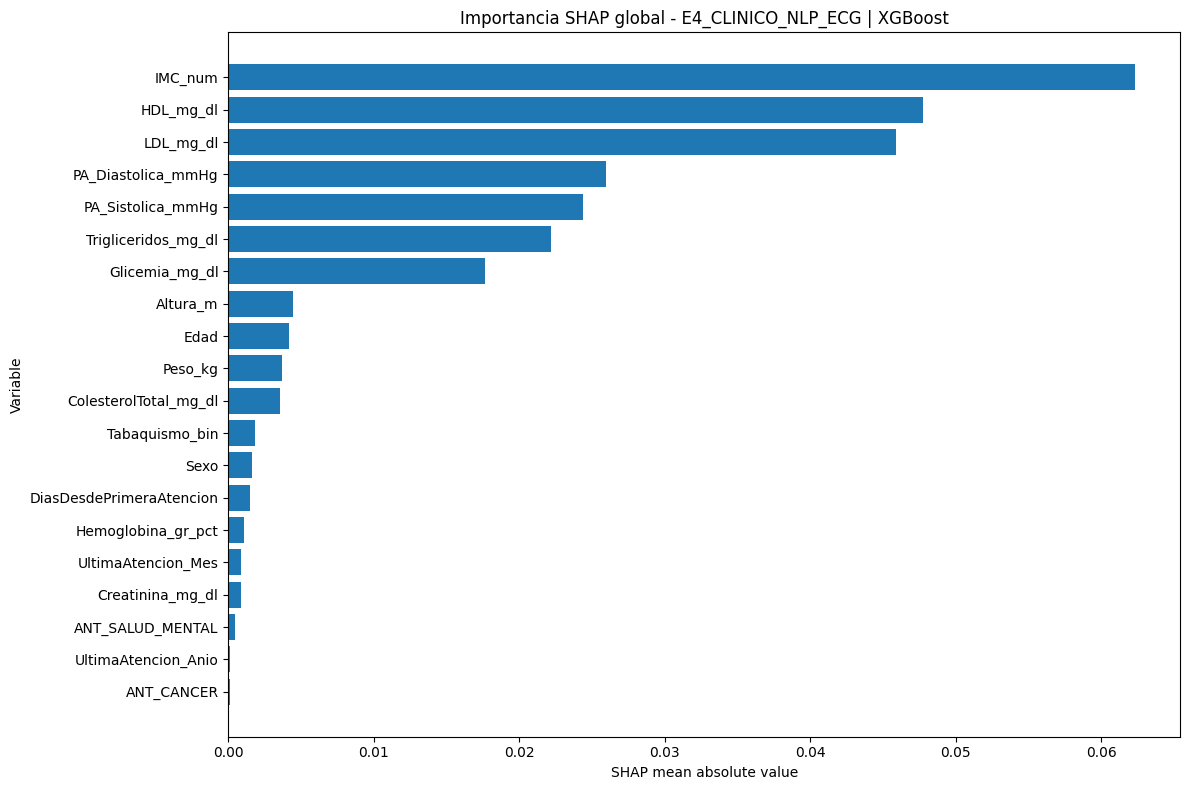

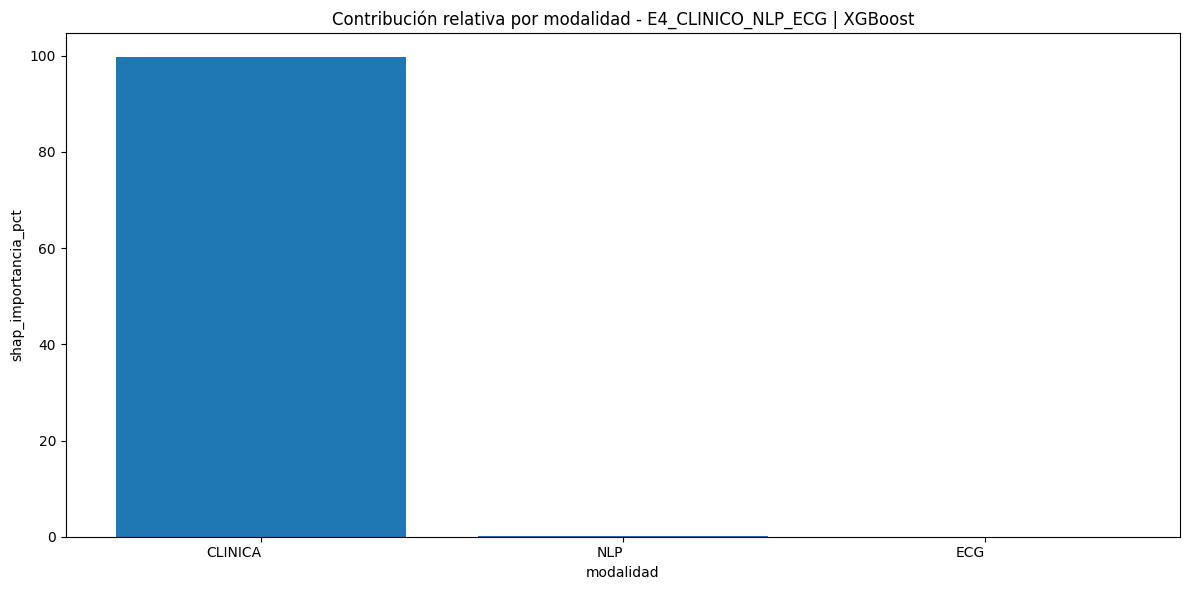

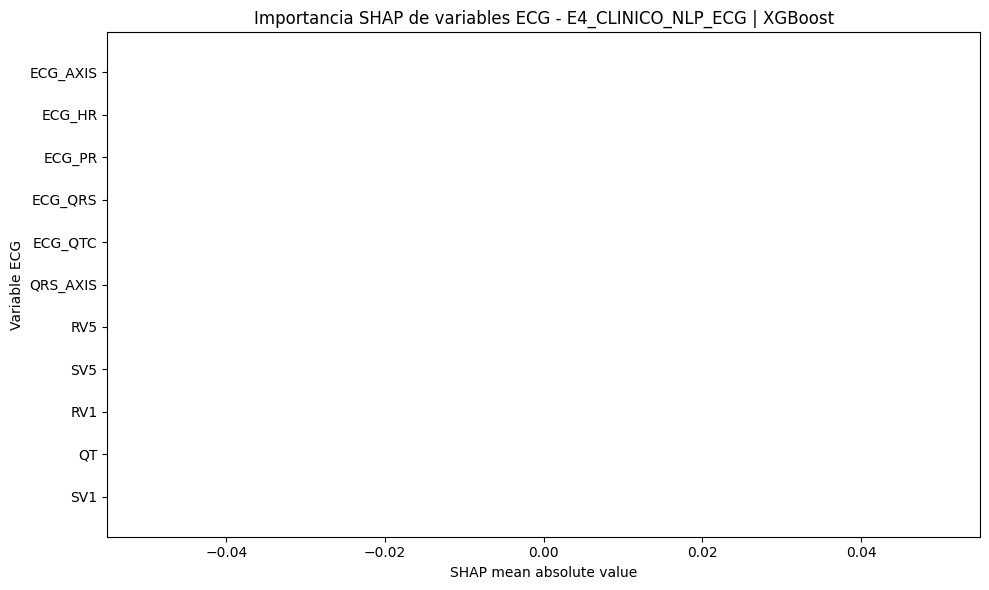

In [10]:
# Gráfico 1: importancia global top 20 del escenario principal
plot_top = principal_importance.head(20).sort_values("shap_abs_mean", ascending=True)
plt.figure(figsize=(12, 8))
plt.barh(plot_top["variable_original"].astype(str), plot_top["shap_abs_mean"])
plt.title(f"Importancia SHAP global - {principal_key[0]} | {principal_key[1]}")
plt.xlabel("SHAP mean absolute value")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(FIG_TOP_VARIABLES, dpi=150)
plt.show()

# Gráfico 2: importancia por modalidad del escenario principal
principal_modality = shap_context[principal_key]["modality"].copy().sort_values("shap_abs_mean", ascending=False)
plot_bar_dataframe(
    principal_modality,
    "modalidad",
    "shap_importancia_pct",
    f"Contribución relativa por modalidad - {principal_key[0]} | {principal_key[1]}",
    FIG_MODALITY,
    rotation=0,
)

# Gráfico 3: variables ECG del escenario principal
ecg_plot = principal_importance[principal_importance["modalidad"].eq("ECG")].copy()
if not ecg_plot.empty:
    ecg_plot = ecg_plot.sort_values("shap_abs_mean", ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(ecg_plot["variable_original"].astype(str), ecg_plot["shap_abs_mean"])
    plt.title(f"Importancia SHAP de variables ECG - {principal_key[0]} | {principal_key[1]}")
    plt.xlabel("SHAP mean absolute value")
    plt.ylabel("Variable ECG")
    plt.tight_layout()
    plt.savefig(FIG_ECG, dpi=150)
    plt.show()
else:
    print("El escenario principal no contiene variables ECG con importancia SHAP agregada.")

## 12. Visualizaciones SHAP nativas

Se generan gráficos SHAP tipo beeswarm y bar sobre el escenario principal.

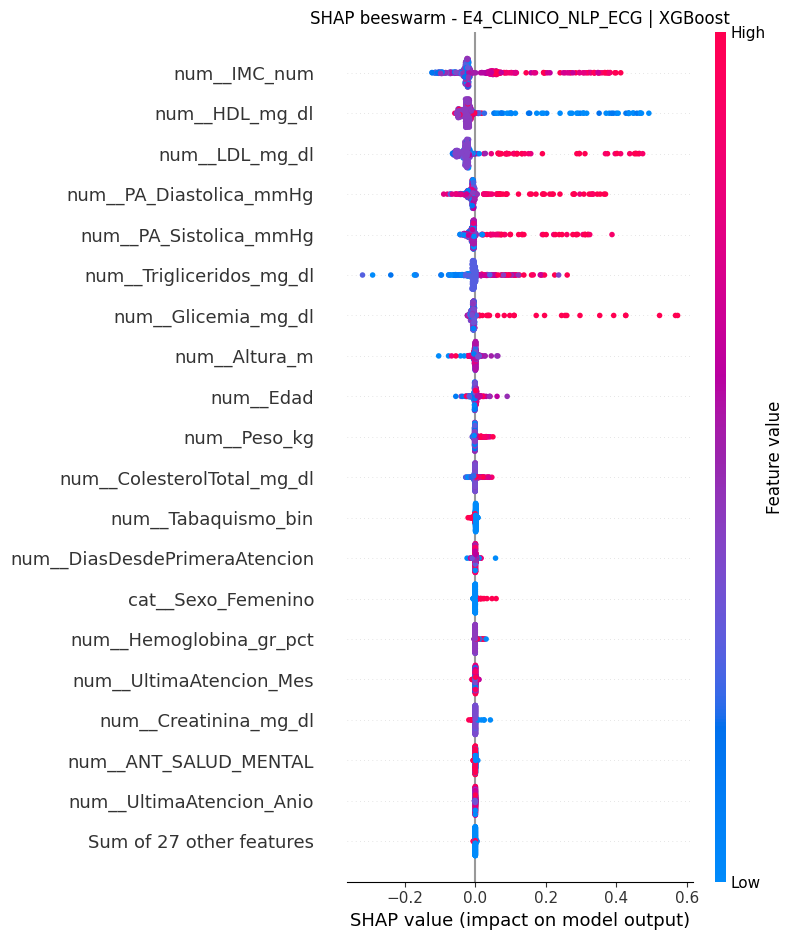

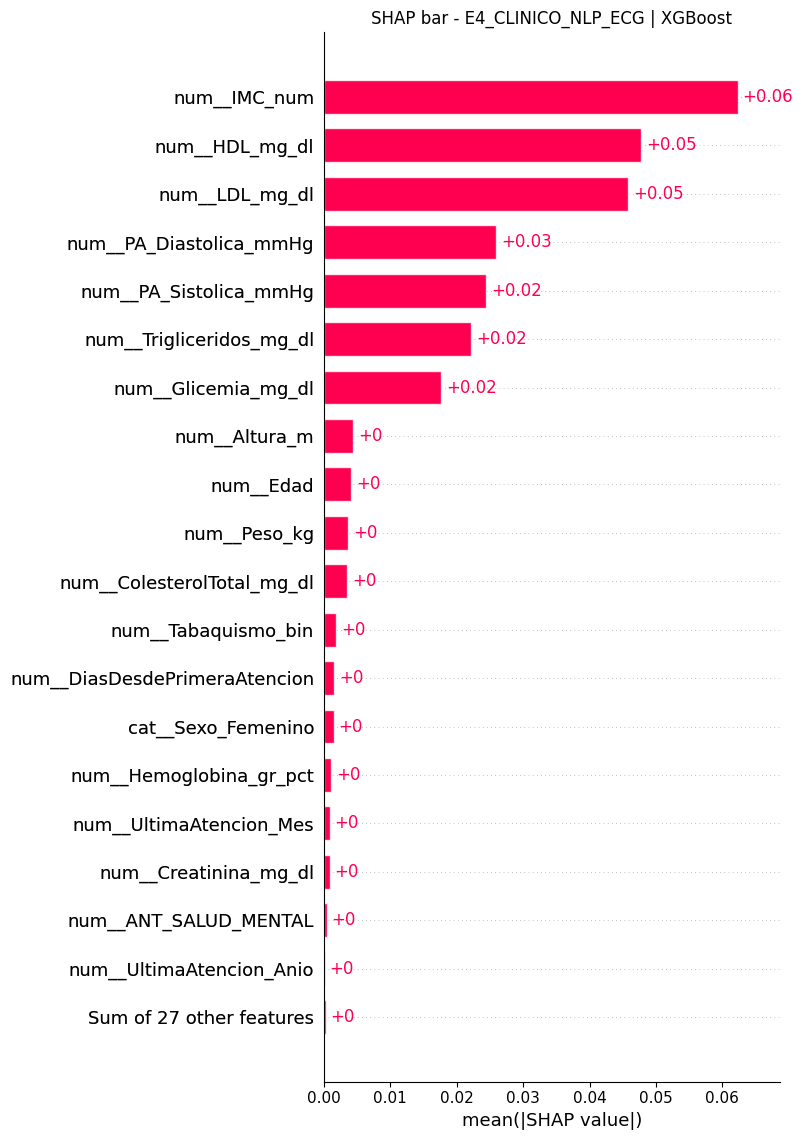

Figuras SHAP globales guardadas:
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Graficos_SHAP\shap_summary_beeswarm.png
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Graficos_SHAP\shap_summary_bar.png


In [11]:
ctx = shap_context[principal_key]
explanation = shap.Explanation(
    values=ctx["shap_matrix"],
    base_values=np.repeat(ctx["expected_value"], ctx["shap_matrix"].shape[0]),
    data=ctx["X_trans_dense"],
    feature_names=ctx["transformed_names"],
)

plt.figure()
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title(f"SHAP beeswarm - {principal_key[0]} | {principal_key[1]}")
plt.tight_layout()
plt.savefig(FIG_SUMMARY_BEESWARM, dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
shap.plots.bar(explanation, max_display=20, show=False)
plt.title(f"SHAP bar - {principal_key[0]} | {principal_key[1]}")
plt.tight_layout()
plt.savefig(FIG_SUMMARY_BAR, dpi=150, bbox_inches="tight")
plt.show()

print("Figuras SHAP globales guardadas:")
print(FIG_SUMMARY_BEESWARM)
print(FIG_SUMMARY_BAR)

## 13. Interpretabilidad local

Se seleccionan casos representativos de alta y baja probabilidad predicha para generar gráficos waterfall.

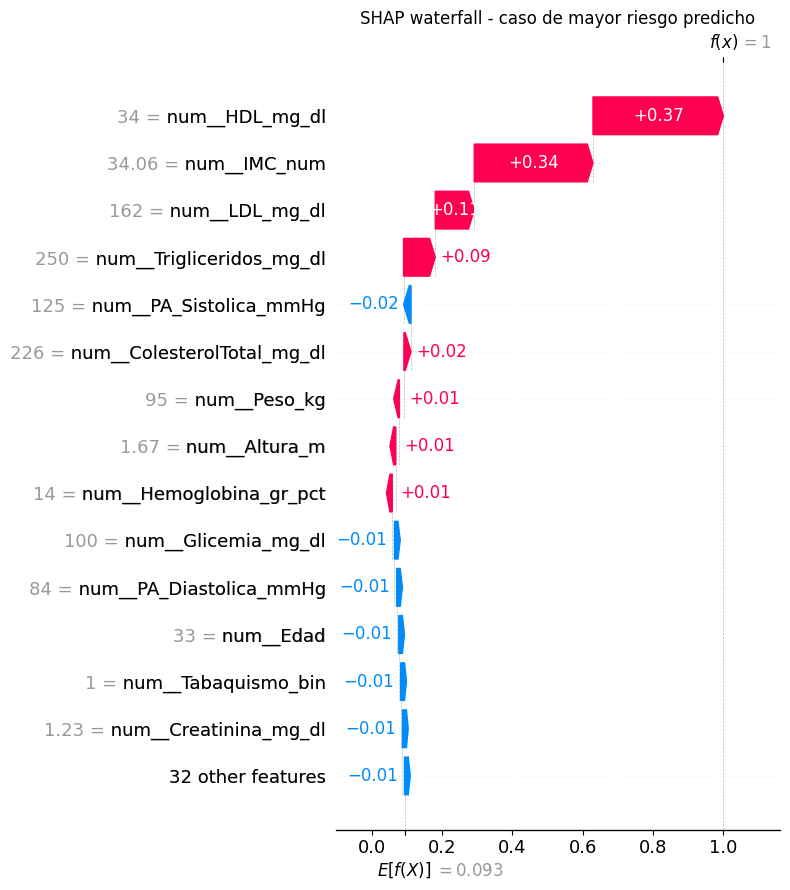

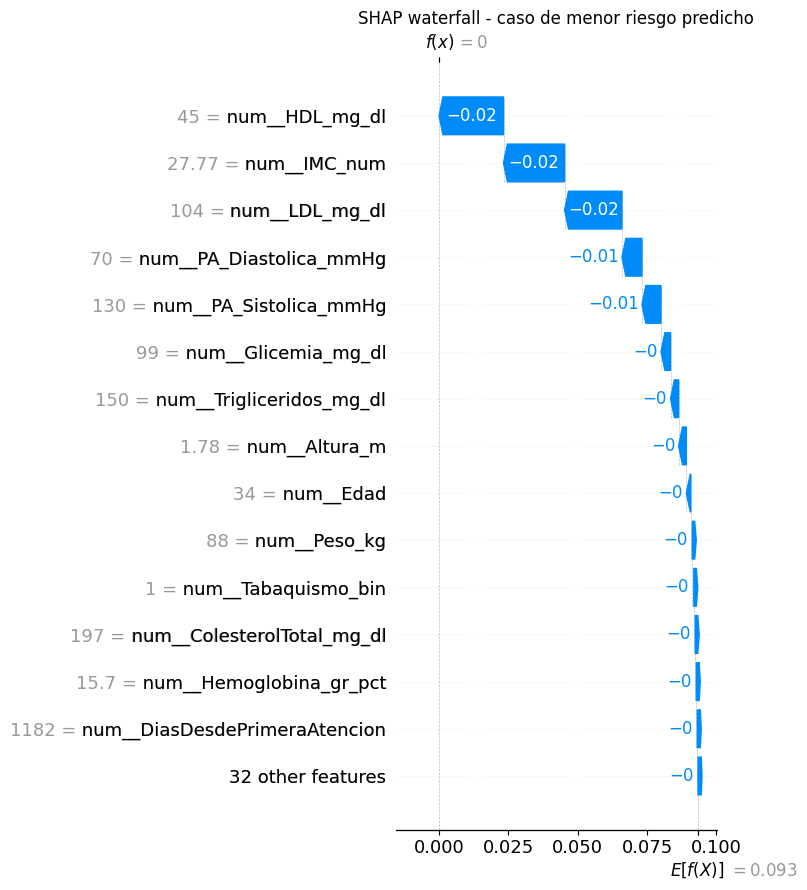

Force plot HTML guardado: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Graficos_SHAP\shap_force_plot_sample.html


,escenario,modelo,index_original,y_real,y_pred,y_score,PACIENTE_ID,REGISTRO_ID,SUBSET_BATERIA,SUBSET_EXAMENES,BATERIA_CLUSTER
227,E4_CLINICO_NLP_ECG,XGBoost,705,1,1,0.999834,PAC_003595,REG_003595,BATERIA_A,BATERIA_A,2
368,E4_CLINICO_NLP_ECG,XGBoost,2807,0,0,0.000022,PAC_003271,REG_003271,BATERIA_C,BATERIA_C,3


In [12]:
local_principal = shap_context[principal_key]["local"].copy().reset_index(drop=True)
if local_principal.empty:
    print("No hay registros locales disponibles.")
else:
    idx_high = int(local_principal["y_score"].idxmax())
    idx_low = int(local_principal["y_score"].idxmin())

    high_exp = explanation[idx_high]
    low_exp = explanation[idx_low]

    plt.figure()
    shap.plots.waterfall(high_exp, max_display=15, show=False)
    plt.title("SHAP waterfall - caso de mayor riesgo predicho")
    plt.tight_layout()
    plt.savefig(FIG_WATERFALL_HIGH, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure()
    shap.plots.waterfall(low_exp, max_display=15, show=False)
    plt.title("SHAP waterfall - caso de menor riesgo predicho")
    plt.tight_layout()
    plt.savefig(FIG_WATERFALL_LOW, dpi=150, bbox_inches="tight")
    plt.show()

    try:
        force_plot = shap.plots.force(high_exp, matplotlib=False)
        shap.save_html(str(HTML_FORCE_SAMPLE), force_plot)
        print("Force plot HTML guardado:", HTML_FORCE_SAMPLE)
    except Exception as exc:
        print("No fue posible generar force plot HTML:", repr(exc))

    display(local_principal.loc[[idx_high, idx_low]])

## 14. Resumen cuantitativo del aporte ECG en interpretabilidad

Se calcula si las variables ECG aparecen en el top 10 y top 20 del ranking SHAP, y la proporción de importancia asociada a ECG por escenario interpretado.

In [13]:
ecg_summary_rows = []
for (scenario, model_name), ctx in shap_context.items():
    imp = ctx["importance"].copy()
    mod = ctx["modality"].copy()
    ecg_imp = imp[imp["modalidad"].eq("ECG")].copy()
    total_importance = imp["shap_abs_mean"].sum()
    ecg_importance = ecg_imp["shap_abs_mean"].sum()
    ecg_pct = ecg_importance / total_importance * 100 if total_importance > 0 else 0
    ecg_summary_rows.append({
        "escenario": scenario,
        "modelo": model_name,
        "n_variables_total": int(imp["variable_original"].nunique()),
        "n_variables_ecg": int(ecg_imp["variable_original"].nunique()),
        "importancia_ecg_total": float(ecg_importance),
        "importancia_ecg_pct": float(ecg_pct),
        "ecg_en_top_10": bool((ecg_imp["rank_global"] <= 10).any()) if not ecg_imp.empty else False,
        "ecg_en_top_20": bool((ecg_imp["rank_global"] <= 20).any()) if not ecg_imp.empty else False,
        "mejor_variable_ecg": ecg_imp.sort_values("rank_global").iloc[0]["variable_original"] if not ecg_imp.empty else "NO_DISPONIBLE",
        "mejor_rank_ecg": int(ecg_imp["rank_global"].min()) if not ecg_imp.empty else None,
    })

ecg_summary = pd.DataFrame(ecg_summary_rows)
display(ecg_summary)

,escenario,modelo,n_variables_total,n_variables_ecg,importancia_ecg_total,importancia_ecg_pct,ecg_en_top_10,ecg_en_top_20,mejor_variable_ecg,mejor_rank_ecg
0,E4_CLINICO_NLP_ECG,XGBoost,45,11,0.0,0.0,False,False,SV1,22
1,E3_CLINICO_ECG,XGBoost,33,11,0.0,0.0,False,True,SV5,19


## 15. Exportación de resultados

Se exportan tablas de importancia global, importancia por modalidad, variables ECG, análisis estructural y casos locales.

In [14]:
config_rows = []
for (scenario, model_name), ctx in shap_context.items():
    config_rows.append({
        "escenario": scenario,
        "modelo": model_name,
        "ruta_modelo": ctx["model_path"],
        "n_muestra_shap": int(ctx["shap_matrix"].shape[0]),
        "n_features_transformadas": int(ctx["shap_matrix"].shape[1]),
        "n_features_originales": int(len(ctx["feature_cols"])),
        "expected_value": extract_numeric_scalar(ctx["expected_value"]),
        "explainer_type": ctx.get("explainer_type", "NO_REGISTRADO"),
    })
configuracion_modelo = pd.DataFrame(config_rows)

with pd.ExcelWriter(OUT_EXCEL, engine="xlsxwriter") as writer:
    importance_global.to_excel(writer, sheet_name="IMPORTANCIA_GLOBAL", index=False)
    importance_modality.to_excel(writer, sheet_name="IMPORTANCIA_MODALIDAD", index=False)
    importance_ecg.to_excel(writer, sheet_name="IMPORTANCIA_ECG", index=False)
    principal_importance.head(20).to_excel(writer, sheet_name="TOP_VARIABLES", index=False)
    ecg_summary.to_excel(writer, sheet_name="RESUMEN_ECG", index=False)
    local_interpretability.to_excel(writer, sheet_name="INTERPRETABILIDAD_LOCAL", index=False)
    configuracion_modelo.to_excel(writer, sheet_name="CONFIGURACION_MODELO", index=False)
    if not shap_by_battery.empty:
        shap_by_battery.to_excel(writer, sheet_name="SHAP_POR_BATERIA", index=False)

print("Archivo Excel exportado:", OUT_EXCEL)

Archivo Excel exportado: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Resultados_SHAP_TFM.xlsx


## 16. Reporte técnico

El reporte resume el modelo interpretado, la contribución relativa por modalidad y la participación de variables ECG.

In [15]:
lines = []
lines.append("REPORTE DE INTERPRETABILIDAD SHAP - TFM")
lines.append("=" * 70)
lines.append(f"Fecha de generación: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
lines.append("")
lines.append("MODELOS INTERPRETADOS")
lines.append("-" * 70)
for _, r in configuracion_modelo.iterrows():
    lines.append(f"Escenario: {r['escenario']} | Modelo: {r['modelo']} | muestra SHAP: {r['n_muestra_shap']} | features transformadas: {r['n_features_transformadas']}")
lines.append("")

lines.append("ESCENARIO PRINCIPAL")
lines.append("-" * 70)
lines.append(f"Escenario principal interpretado: {principal_key[0]}")
lines.append(f"Modelo principal interpretado: {principal_key[1]}")
lines.append("")

lines.append("TOP 10 VARIABLES POR IMPORTANCIA SHAP")
lines.append("-" * 70)
for _, r in principal_importance.head(10).iterrows():
    lines.append(f"{int(r['rank_global']):02d}. {r['variable_original']} | modalidad={r['modalidad']} | SHAP_abs_mean={r['shap_abs_mean']:.6f} | pct={r['shap_importancia_pct']:.2f}%")
lines.append("")

lines.append("CONTRIBUCIÓN POR MODALIDAD")
lines.append("-" * 70)
for _, r in shap_context[principal_key]["modality"].iterrows():
    lines.append(f"{r['modalidad']}: {r['shap_importancia_pct']:.2f}%")
lines.append("")

lines.append("RESUMEN ECG")
lines.append("-" * 70)
for _, r in ecg_summary.iterrows():
    lines.append(
        f"{r['escenario']} | {r['modelo']} | importancia ECG={r['importancia_ecg_pct']:.2f}% | "
        f"ECG top10={r['ecg_en_top_10']} | ECG top20={r['ecg_en_top_20']} | "
        f"mejor ECG={r['mejor_variable_ecg']} | rank={r['mejor_rank_ecg']}"
    )
lines.append("")

if not shap_by_battery.empty:
    lines.append("ANÁLISIS ESTRUCTURAL")
    lines.append("-" * 70)
    lines.append("Se generaron importancias SHAP por SUBSET_BATERIA.")
else:
    lines.append("ANÁLISIS ESTRUCTURAL")
    lines.append("-" * 70)
    lines.append("No se generó SHAP por batería por ausencia de columna estructural compatible o muestra insuficiente por subconjunto.")
lines.append("")

lines.append("CONSIDERACIÓN METODOLÓGICA")
lines.append("-" * 70)
lines.append("Los valores SHAP se utilizan para interpretar modelos previamente entrenados dentro del pipeline experimental. No constituyen evidencia clínica causal ni validación diagnóstica.")

report_text = "\n".join(lines)
with open(OUT_REPORT, "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print("\nReporte exportado:", OUT_REPORT)

REPORTE DE INTERPRETABILIDAD SHAP - TFM
Fecha de generación: 2026-07-22 09:41:05

MODELOS INTERPRETADOS
----------------------------------------------------------------------
Escenario: E4_CLINICO_NLP_ECG | Modelo: XGBoost | muestra SHAP: 500 | features transformadas: 46
Escenario: E3_CLINICO_ECG | Modelo: XGBoost | muestra SHAP: 500 | features transformadas: 34

ESCENARIO PRINCIPAL
----------------------------------------------------------------------
Escenario principal interpretado: E4_CLINICO_NLP_ECG
Modelo principal interpretado: XGBoost

TOP 10 VARIABLES POR IMPORTANCIA SHAP
----------------------------------------------------------------------
01. IMC_num | modalidad=CLINICA | SHAP_abs_mean=0.062287 | pct=23.03%
02. HDL_mg_dl | modalidad=CLINICA | SHAP_abs_mean=0.047763 | pct=17.66%
03. LDL_mg_dl | modalidad=CLINICA | SHAP_abs_mean=0.045855 | pct=16.95%
04. PA_Diastolica_mmHg | modalidad=CLINICA | SHAP_abs_mean=0.025988 | pct=9.61%
05. PA_Sistolica_mmHg | modalidad=CLINICA | SHA

## 17. Consideraciones metodológicas finales

Los resultados generados por este notebook deben interpretarse como evidencia explicativa del comportamiento de modelos entrenados dentro de un pipeline experimental.

SHAP permite estimar contribuciones relativas de variables en las predicciones del modelo, pero no establece causalidad clínica. La interpretación debe realizarse junto con las métricas predictivas, la evaluación incremental, la disponibilidad de información por subconjunto estructural y las limitaciones declaradas del endpoint operacional `RIESGO_CARDIOMETABOLICO`.